In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
df=pd.read_csv(r'C:\creativa_datasets\fruit_classification.csv')

In [3]:
df.head()

,weight_grams,diameter_cm,sweetness_score,color_score,fruit_type
0,178.1,8.05,5.9,7.4,orange
1,157.5,7.88,5.0,7.1,apple
2,112.8,3.74,8.0,10.0,banana
3,132.1,7.15,5.5,7.1,apple
4,118.4,3.98,7.2,8.6,banana


In [4]:
df['fruit_type'].value_counts()

fruit_type
orange    100
apple     100
banana    100
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   weight_grams     300 non-null    float64
 1   diameter_cm      300 non-null    float64
 2   sweetness_score  300 non-null    float64
 3   color_score      300 non-null    float64
 4   fruit_type       300 non-null    object 
dtypes: float64(4), object(1)
memory usage: 11.8+ KB


In [6]:
X=df.drop('fruit_type',axis=1)
y=df['fruit_type']

In [7]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [8]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [9]:
model = DecisionTreeClassifier(max_depth=3,random_state=42)

model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

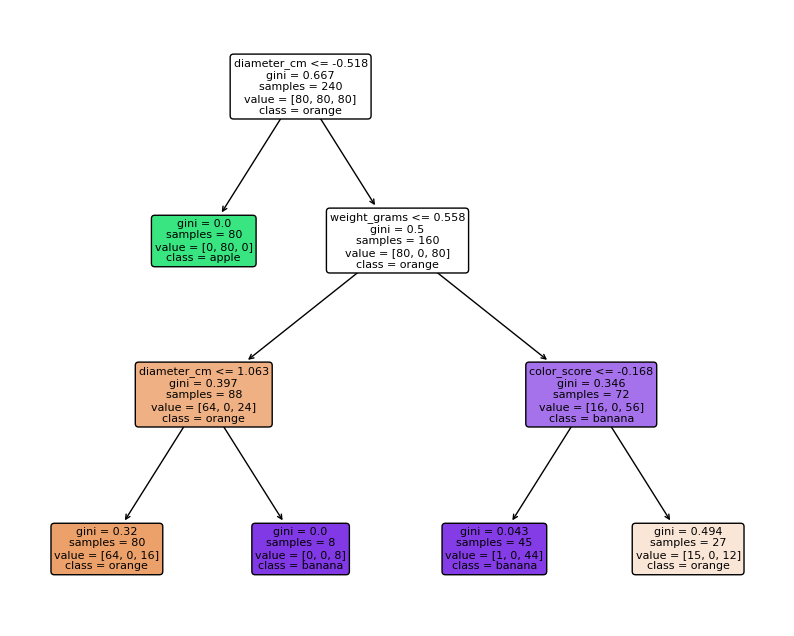

In [10]:
plt.figure(figsize=(10, 8))
plot_tree(model,feature_names=X.columns, class_names=['orange', 'apple', 'banana'], filled=True, rounded=True,fontsize=8)

plt.show()

In [11]:
y_pred = model.predict(x_test)

In [12]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8166666666666667


[[17  0  3]
 [ 0 20  0]
 [ 8  0 12]]


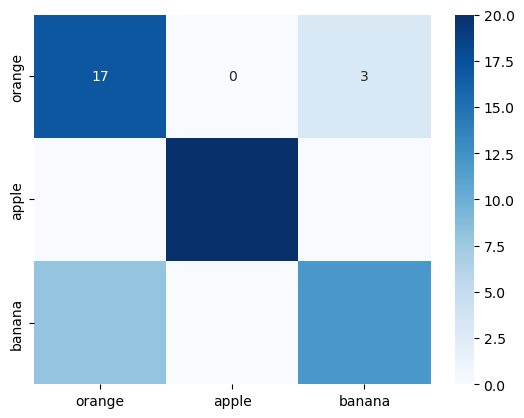

In [13]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['orange', 'apple', 'banana'],yticklabels=['orange', 'apple', 'banana'])
print(cm)